In [10]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import statsmodels.api as sm

In [11]:
stats = pd.read_csv('team_stats_2003_2023.csv')
stats.columns

Index(['year', 'team', 'wins', 'losses', 'win_loss_perc', 'points',
       'points_opp', 'points_diff', 'mov', 'g', 'total_yards', 'plays_offense',
       'yds_per_play_offense', 'turnovers', 'fumbles_lost', 'first_down',
       'pass_cmp', 'pass_att', 'pass_yds', 'pass_td', 'pass_int',
       'pass_net_yds_per_att', 'pass_fd', 'rush_att', 'rush_yds', 'rush_td',
       'rush_yds_per_att', 'rush_fd', 'penalties', 'penalties_yds', 'pen_fd',
       'score_pct', 'turnover_pct', 'exp_pts_tot', 'ties'],
      dtype='object')

In [12]:
missing_values_summary = stats.isna().sum()

print(missing_values_summary.head(6))

year             0
team             0
wins             0
losses           0
win_loss_perc    0
points           0
dtype: int64


In [13]:
stats_cleaned = stats.copy()

def assign_division(team):
    if team in ["New England Patriots", "Miami Dolphins", "Buffalo Bills", "New York Jets"]:
        return "AFC East"
    elif team in ["Denver Broncos", "Las Vegas Raiders", "Kansas City Chiefs", "Los Angeles Chargers", "Oakland Raiders", "San Diego Chargers"]:
        return "AFC West"
    elif team in ["Baltimore Ravens", "Cincinnati Bengals", "Pittsburgh Steelers", "Cleveland Browns"]:
        return "AFC North"
    elif team in ["Houston Texans", "Indianapolis Colts", "Jacksonville Jaguars", "Tennessee Titans"]:
        return "AFC South"
    elif team in ["Chicago Bears", "Detroit Lions", "Green Bay Packers", "Minnesota Vikings"]:
        return "NFC North"
    elif team in ["Arizona Cardinals", "Los Angeles Rams", "San Francisco 49ers", "Seattle Seahawks", "St. Louis Rams"]:
        return "NFC West"
    elif team in ["Atlanta Falcons", "Carolina Panthers", "New Orleans Saints", "Tampa Bay Buccaneers"]:
        return "NFC South"    
    else:
        return "NFC East"

stats_cleaned["division"] = stats_cleaned["team"].apply(lambda team: assign_division(team))

stats_cleaned.name = "Cleaned NFL Data"
stats_cleaned.to_csv('cleaned_team_stats_03_23_nfldata.csv', index=False)

stats_cleaned.head()

value_counts = stats_cleaned['division'].value_counts()

# Print the result
print(value_counts)

division
AFC East     84
AFC North    84
AFC South    84
AFC West     84
NFC East     84
NFC North    84
NFC South    84
NFC West     84
Name: count, dtype: int64


In [24]:
stats_name = stats_cleaned.copy()

# Create mapping
team_name_mapping = {
    "San Diego Chargers": "Los Angeles Chargers",
    "St. Louis Rams": "Los Angeles Rams",
    "Washington Football Team": "Washington Commanders",
    "Washington Redskins": "Washington Commanders",
    "Oakland Raiders": "Las Vegas Raiders"
}

# Apply the team name mapping
stats_name['team'] = stats_name['team'].replace(team_name_mapping)

                                     wins  losses  win_loss_perc  points  \
team                  year division                                        
Arizona Cardinals     2003 NFC West     4      12          0.250     225   
                      2004 NFC West     6      10          0.375     284   
                      2005 NFC West     5      11          0.313     311   
                      2006 NFC West     5      11          0.313     314   
                      2007 NFC West     8       8          0.500     404   
...                                   ...     ...            ...     ...   
Washington Commanders 2019 NFC East     3      13          0.188     266   
                      2020 NFC East     7       9          0.438     335   
                      2021 NFC East     7      10          0.412     335   
                      2022 NFC East     8       8          0.500     321   
                      2023 NFC East     4      13          0.235     329   

           

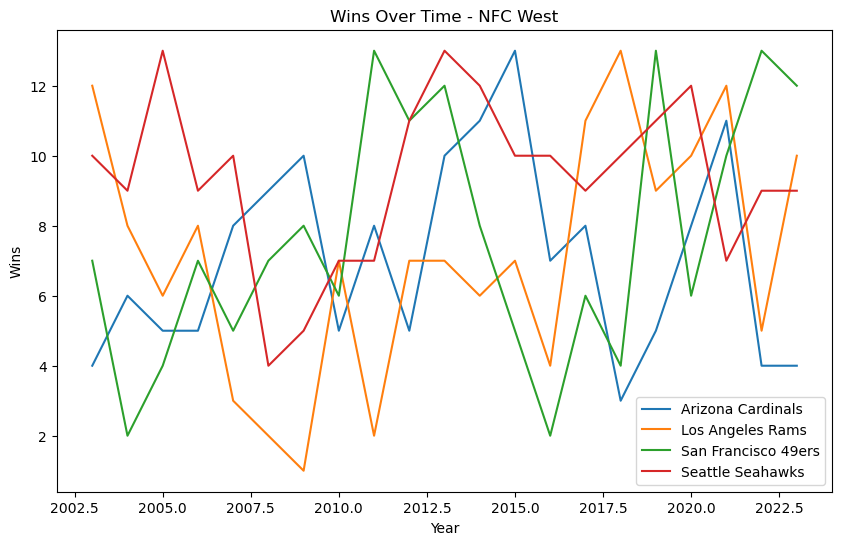

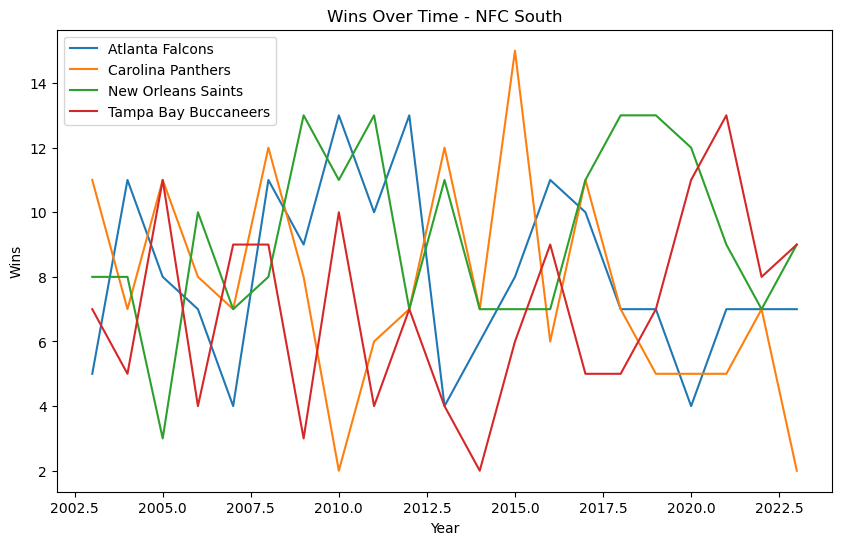

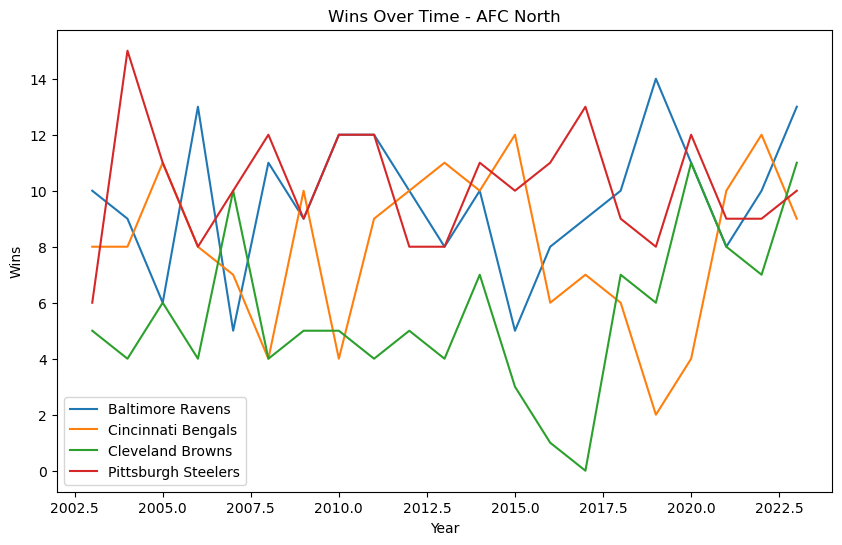

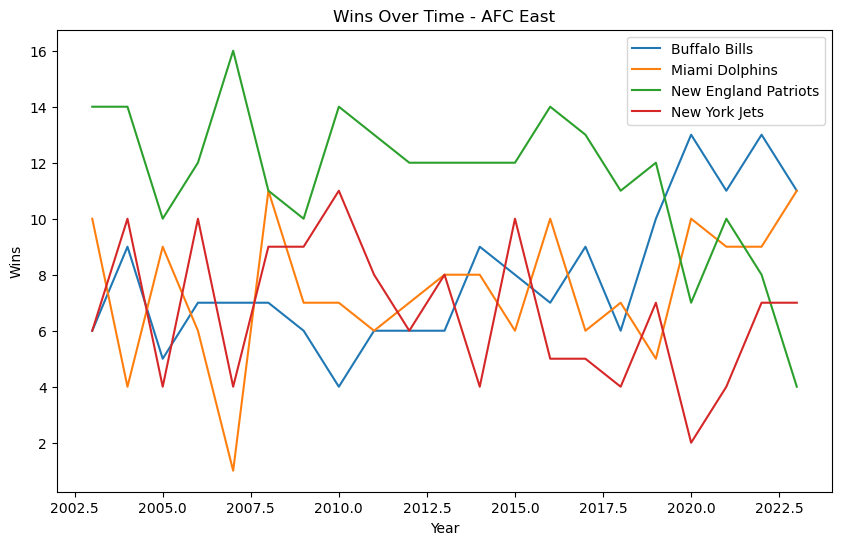

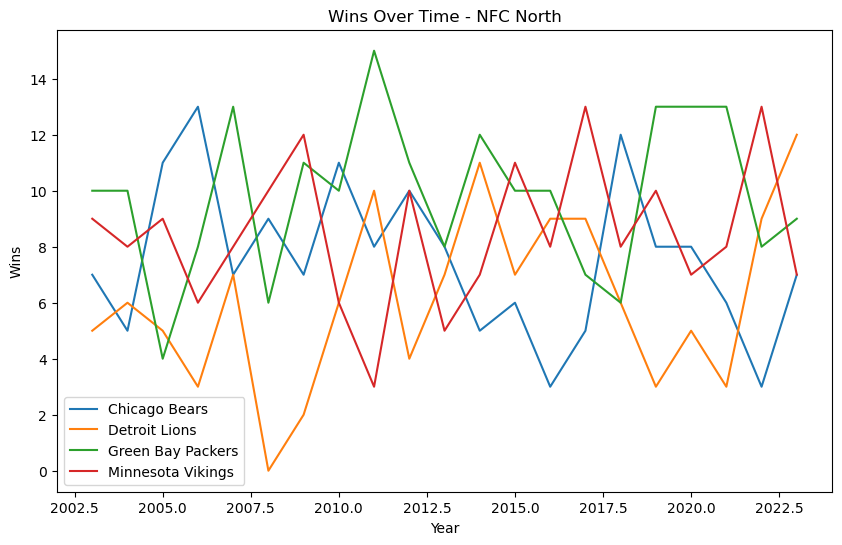

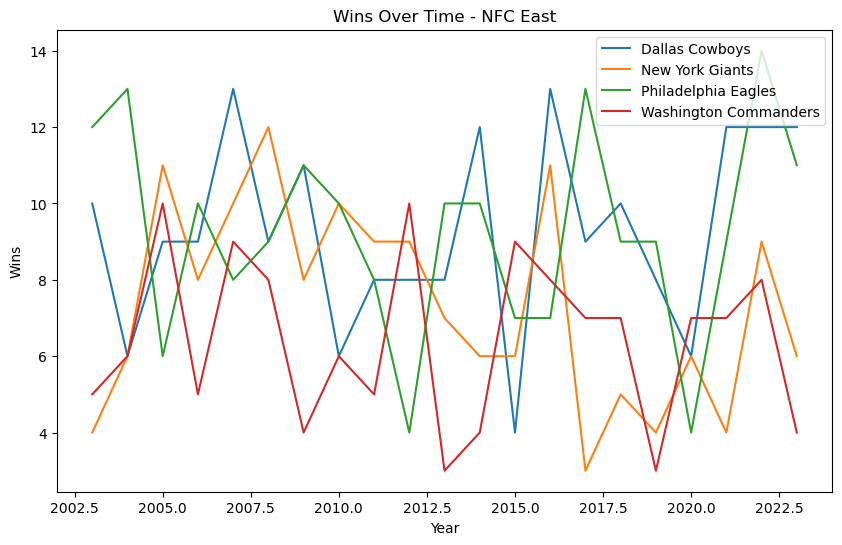

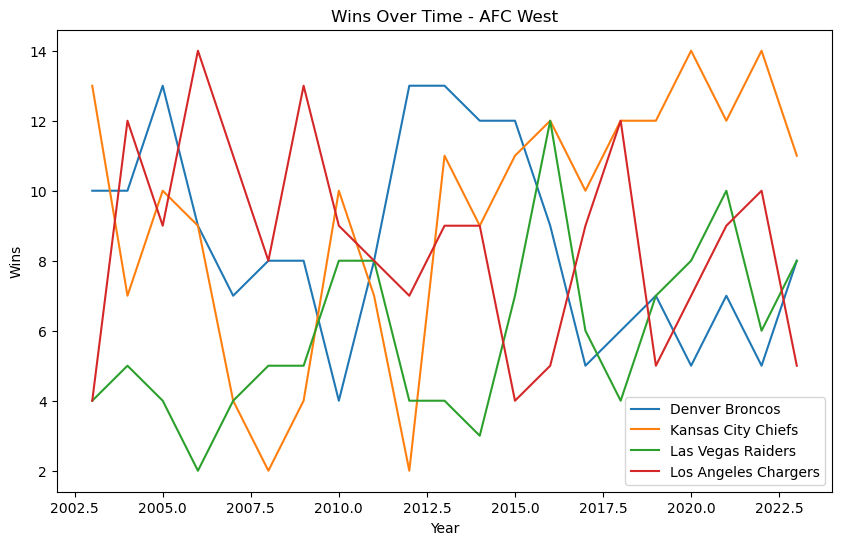

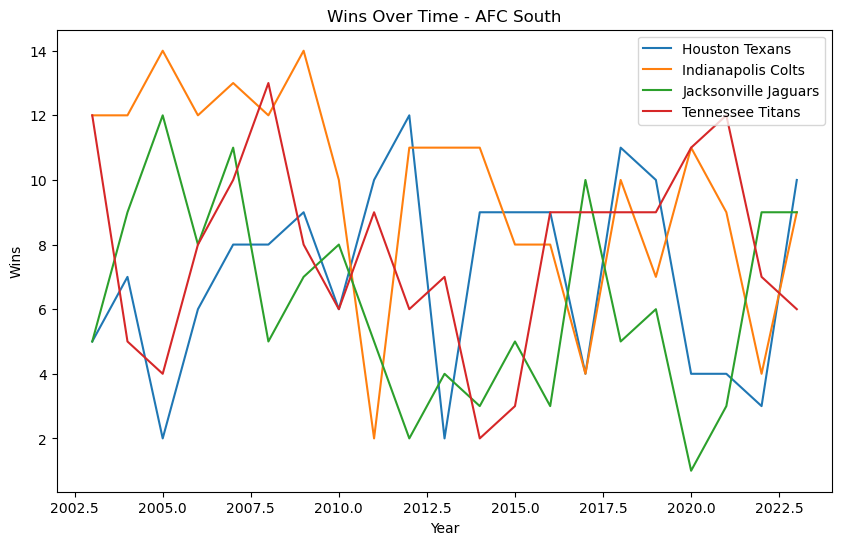

In [26]:
agg_stats = stats_name.groupby(["team", "year", "division"]).sum()
print(agg_stats)

# Get unique divisions
divisions = agg_stats.index.get_level_values("division").unique()

# Plotting for each division
for division in divisions:
    # Filter data for the current division
    division_data = agg_stats.xs(division, level="division")
    
    # Create the plot
    plt.figure(figsize=(10, 6))
    for team, team_data in division_data.groupby("team"):
        plt.plot(team_data.index.get_level_values("year"), team_data["wins"], label=team)
    
    plt.title(f"Wins Over Time - {division}")
    plt.xlabel("Year")
    plt.ylabel("Wins")
    plt.legend()
    plt.show()

Correlation Matrix: Total Yards vs Points vs Wins
             total_yards    points      wins
total_yards     1.000000  0.837513  0.548353
points          0.837513  1.000000  0.753723
wins            0.548353  0.753723  1.000000


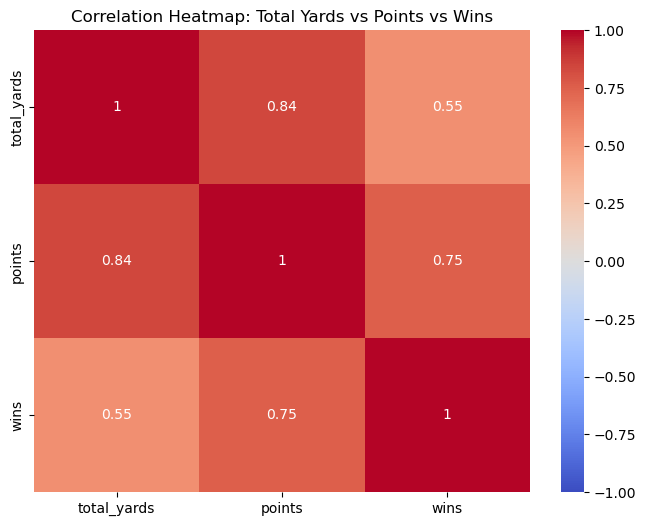

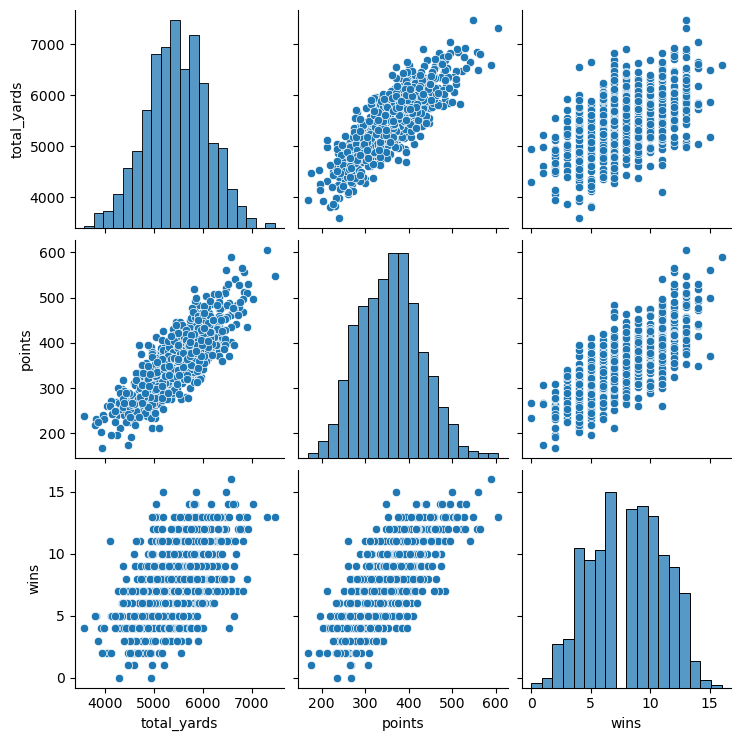

In [31]:
# Perform correlation analysis
correlation_matrix = stats_name[['total_yards', 'points', 'wins']].corr()

# Print correlation matrix
print("Correlation Matrix: Total Yards vs Points vs Wins")
print(correlation_matrix)

# Visualize the correlation matrix using a heatmap and scatterplot
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation Heatmap: Total Yards vs Points vs Wins')
plt.show()

# Scatter plot
sns.pairplot(stats_name[['total_yards', 'points', 'wins']])
plt.show()